# Biblioteca

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
import xgboost as xgb

# Dataset

In [2]:
# Carregar o dataset Titanic
df = pd.read_csv(r"C:\Python\Kaggle\Bank Marketing Dataset\bank-full.csv", sep=";")
# Exibir as primeiras linhas do dataset
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
"""
Comentario: 
age: Idade do cliente
job: Cargo do cliente
marital: Estado civil do cliente
education: Nível de escolaridade do cliente
default: Possui crédito em inadimplência?
balance: Se o cliente possui financiamento imobiliário
housing: Possui Empréstimo Pessoal
loan: Saldo individual do cliente
contact: Tipo de comunicação do contato
day: Último dia da semana de contato
month: Último mês do ano de contato
duration: Duração do último contato, em segundos
campaign: Número de contatos realizados durante esta campanha e para este cliente
pdias: Número de dias decorridos desde o último contato do cliente em uma campanha anterior
previous: Número de contatos realizados antes desta campanha e para este cliente
poutcome: da campanha de marketing anterior
y: o cliente subscreveu um depósito a prazo
"""

'\nComentario: \nage: Idade do cliente\njob: Cargo do cliente\nmarital: Estado civil do cliente\neducation: Nível de escolaridade do cliente\ndefault: Possui crédito em inadimplência?\nbalance: Se o cliente possui financiamento imobiliário\nhousing: Possui Empréstimo Pessoal\nloan: Saldo individual do cliente\ncontact: Tipo de comunicação do contato\nday: Último dia da semana de contato\nmonth: Último mês do ano de contato\nduration: Duração do último contato, em segundos\ncampaign: Número de contatos realizados durante esta campanha e para este cliente\npdias: Número de dias decorridos desde o último contato do cliente em uma campanha anterior\nprevious: Número de contatos realizados antes desta campanha e para este cliente\npoutcome: da campanha de marketing anterior\ny: o cliente subscreveu um depósito a prazo\n'

In [4]:
# Transformar a coluna mes em numeros
mapa_meses = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12,
}

# --- Aplicar o mapeamento na coluna 'month' ---
df["month"] = df["month"].map(mapa_meses)

In [5]:
# Transformando a colunas de saida Y de no para 0 e yes para 1
mapa_y = {"no": 0, "yes": 1}

# --- Aplicar o mapeamento na coluna 'y' ---
df["y"] = df["y"].map(mapa_y)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  int64 
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  int64 
dtypes: int64(9), object(8)
memory usage: 5.9+ MB


In [7]:
"""
Comentario: Não possui nenhum dado faltante.
"""

'\nComentario: Não possui nenhum dado faltante.\n'

In [8]:
"""
Comentario: 15 atributos e y de saida. Sendo 7 valores inteiros e 9 objetos, mais a saida que é um objeto.
"""

'\nComentario: 15 atributos e y de saida. Sendo 7 valores inteiros e 9 objetos, mais a saida que é um objeto.\n'

# Analise Exploratoria do Dataset

In [9]:
# Exibir estatísticas descritivas
df.describe()

,age,balance,day,month,duration,campaign,pdays,previous,y
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,6.144655,258.163080,2.763841,40.197828,0.580323,0.116985
std,10.618762,3044.765829,8.322476,2.408034,257.527812,3.098021,100.128746,2.303441,0.321406
min,18.000000,-8019.000000,1.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,5.000000,103.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,448.000000,16.000000,6.000000,180.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1428.000000,21.000000,8.000000,319.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,102127.000000,31.000000,12.000000,4918.000000,63.000000,871.000000,275.000000,1.000000


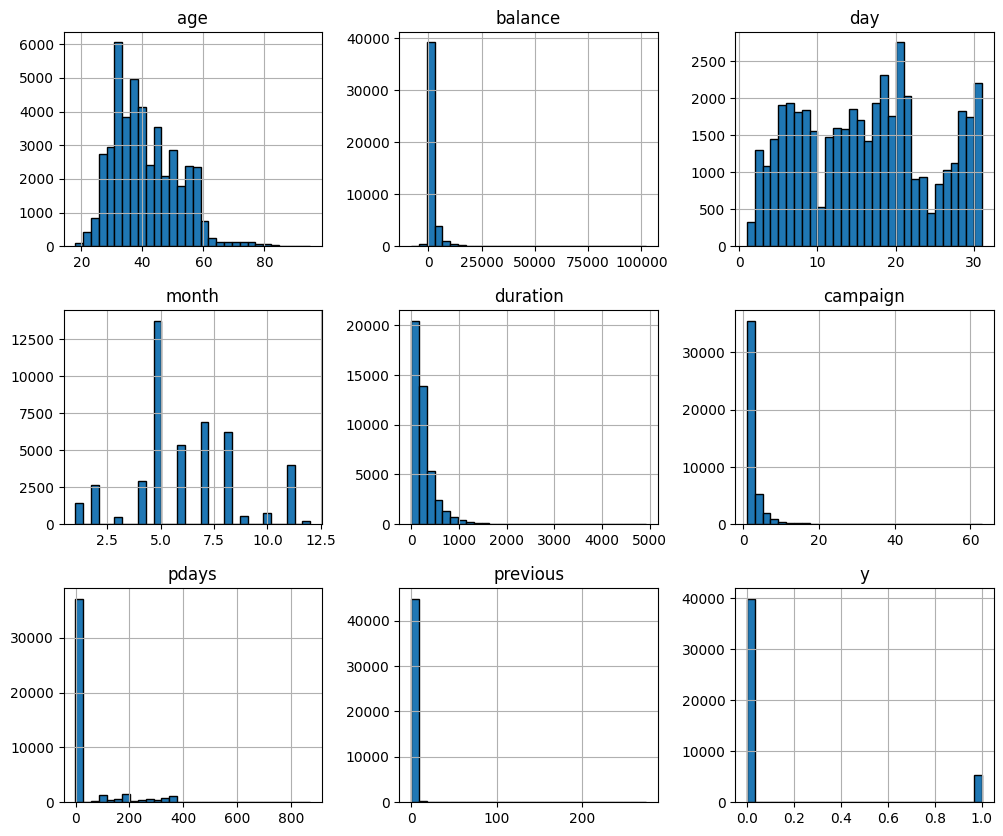

In [10]:
# Histograma para visualizar a distribuição das variáveis
df.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.show()

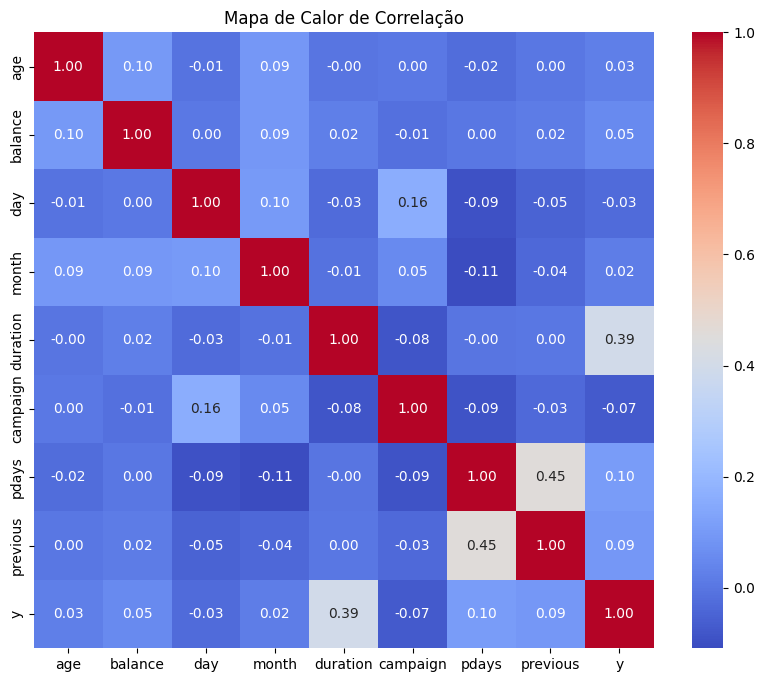

In [11]:
# Mapa de calor das variaveis numericas
plt.figure(figsize=(10, 8))
# Selecionar apenas colunas numéricas para a correlação
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de Calor de Correlação")
plt.show()

In [12]:
"""
Comentario: Não possui nenhuma variavel numerica muito parecida entre si.
"""

'\nComentario: Não possui nenhuma variavel numerica muito parecida entre si.\n'

In [13]:
# Separar variáveis numéricas e textuais
variaveis_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
variaveis_textuais = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Exibir os resultados
print("Variáveis Numéricas:")
print(variaveis_numericas)

print("\nVariáveis Textuais:")
print(variaveis_textuais)

Variáveis Numéricas:
['age', 'balance', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'y']

Variáveis Textuais:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']


In [14]:
# Lista das colunas numericas que vão ser analisadas se tem outliers
colunas_numericas = [
    "age",
    "balance",
    "day",
    "month",
    "duration",
    "campaign",
    "pdays",
    "previous",
]

# Crie a cópia com as colunas selecionadas
df_numerico = df[colunas_numericas].copy()

# Definir o limite de outliers com base no IQR (Intervalo Interquartil)
Q1 = df_numerico.quantile(0.25)
Q3 = df_numerico.quantile(0.75)
IQR = Q3 - Q1

# Definir limites inferior e superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar quantos valores estão fora desses limites
outliers = ((df_numerico < limite_inferior) | (df_numerico > limite_superior)).sum()
outliers

age          487
balance     4729
day            0
month          0
duration    3235
campaign    3064
pdays       8257
previous    8257
dtype: int64

In [15]:
"""
Comentario: Apenas a variavel day e month não tem um outliers, o que é totalmente esperado.
O atributo age possui 1,08% de outliers, um resultado ok.
O atributo balance possui 10,46% de outliers, um resultado muito grande.
O atributo duration possui 7,16% de outliers, um resultado muito grande.
O atributo camign possui 6,78% de outliers, um resultado muito grande.
o atributo pdays possui 18,26% de outliers, um resultado muito estranho, já que isso demostra que não é nenhum pouco equilibrado.
O atributo previous possui 18,26% de outliers, um resultado muito estranho, já que isso demostra que não é nenhum pouco equilibrado.
"""

'\nComentario: Apenas a variavel day e month não tem um outliers, o que é totalmente esperado.\nO atributo age possui 1,08% de outliers, um resultado ok.\nO atributo balance possui 10,46% de outliers, um resultado muito grande.\nO atributo duration possui 7,16% de outliers, um resultado muito grande.\nO atributo camign possui 6,78% de outliers, um resultado muito grande.\no atributo pdays possui 18,26% de outliers, um resultado muito estranho, já que isso demostra que não é nenhum pouco equilibrado.\nO atributo previous possui 18,26% de outliers, um resultado muito estranho, já que isso demostra que não é nenhum pouco equilibrado.\n'

Exibindo gráficos para as colunas textuais:


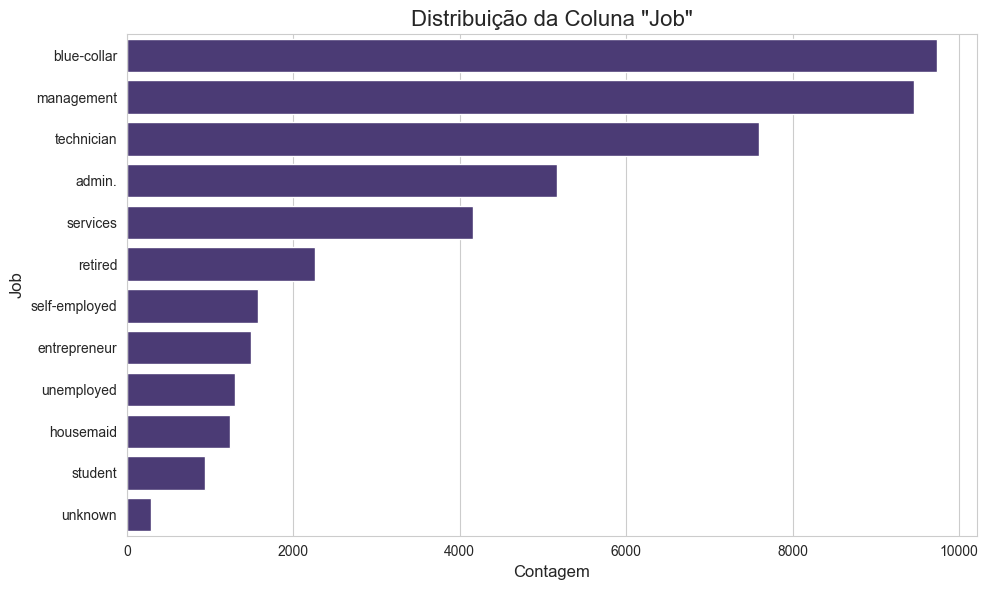

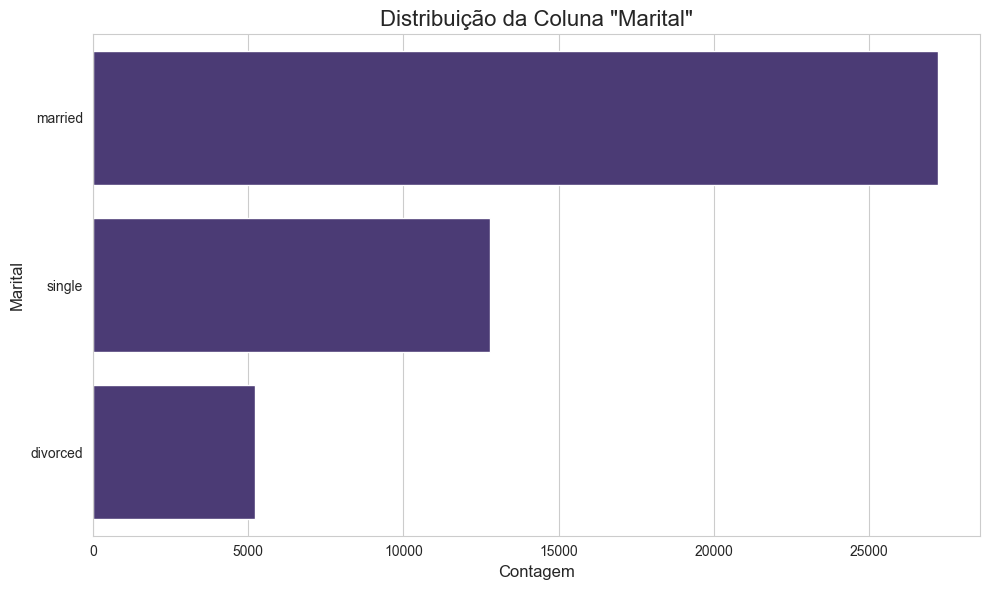

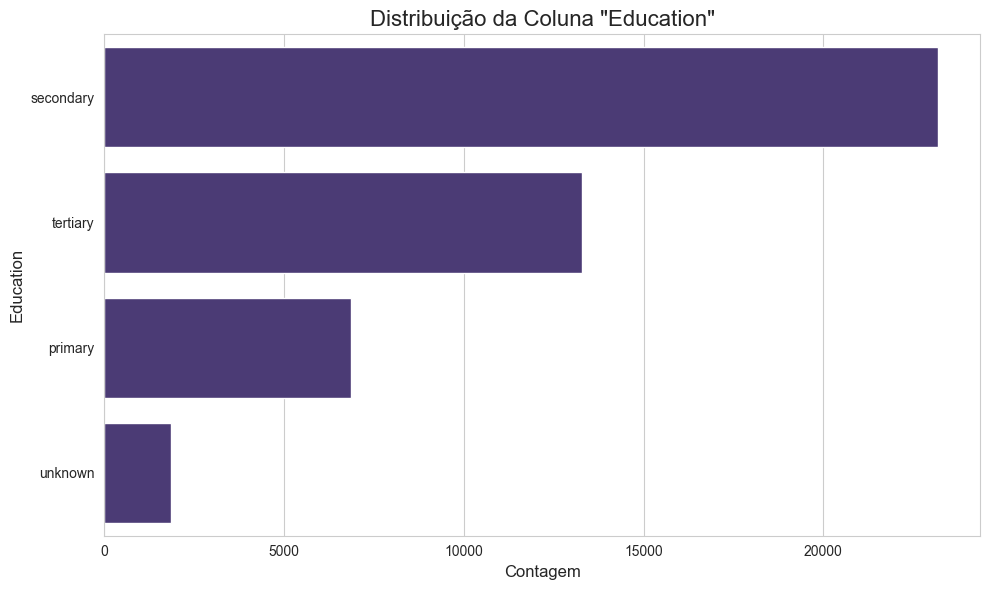

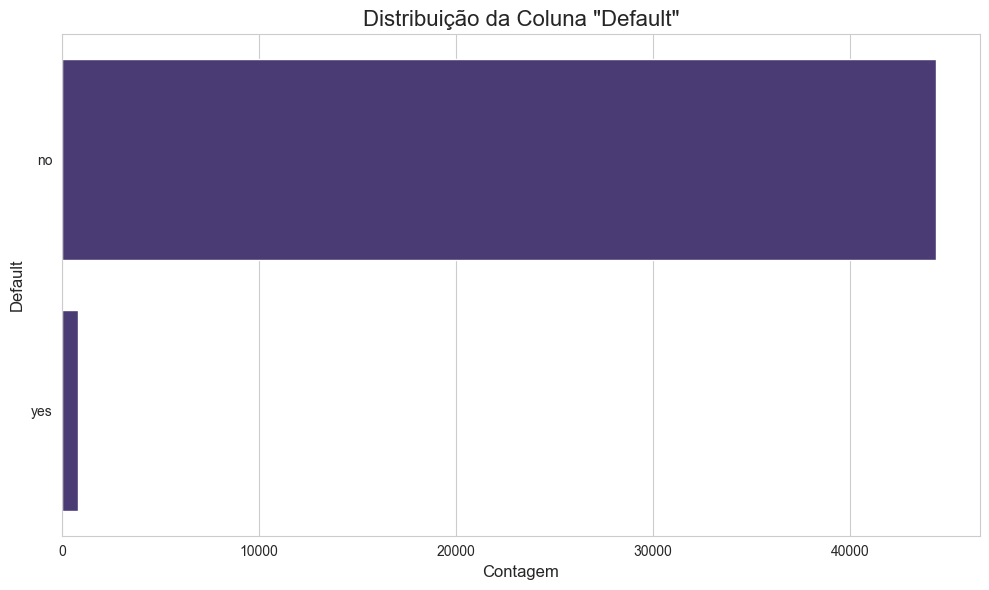

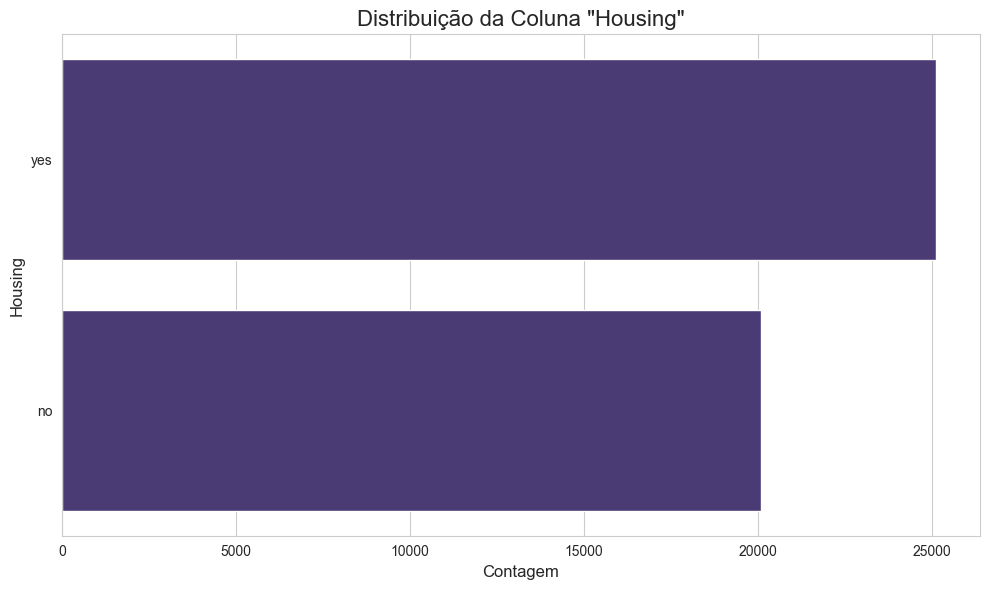

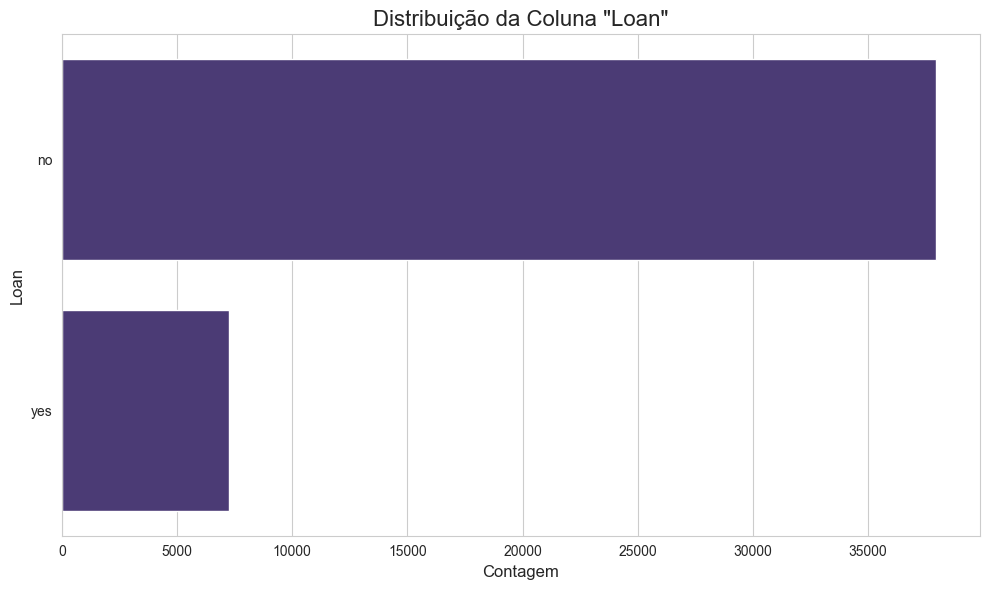

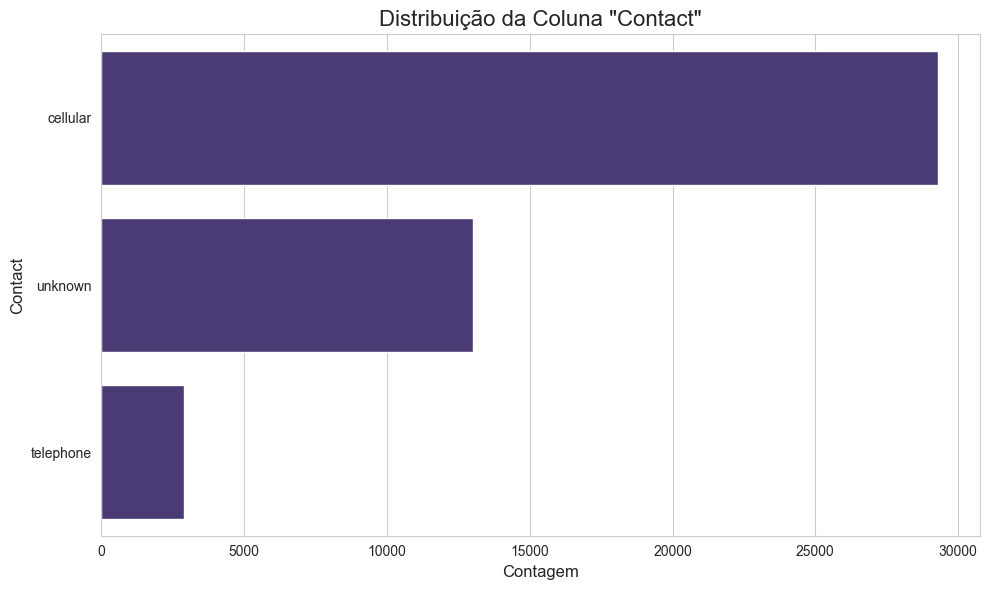

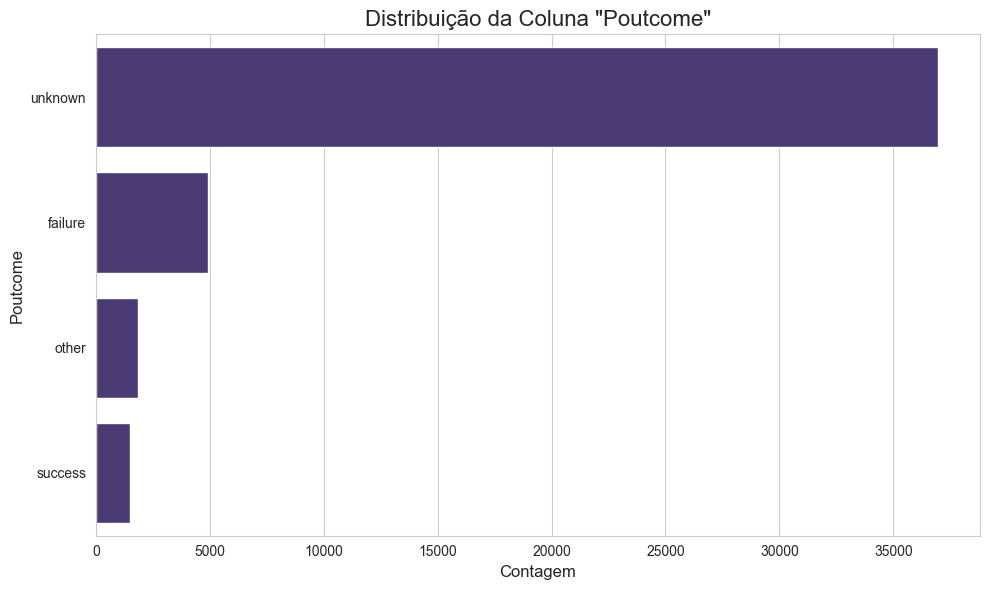

In [16]:
# Balanço dos atributos textuais
colunas_textuais = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "poutcome",
]

# Define um estilo visual mais agradável para os gráficos
sns.set_style("whitegrid")
sns.set_palette("viridis")

# Loop para criar e exibir um gráfico para cada coluna
print("Exibindo gráficos para as colunas textuais:")

for coluna in colunas_textuais:
    plt.figure(figsize=(10, 6))

    # Cria o gráfico de contagem (plotado na horizontal para melhor leitura dos rótulos)
    sns.countplot(y=coluna, data=df, order=df[coluna].value_counts().index)

    # Adiciona títulos e rótulos
    plt.title(f'Distribuição da Coluna "{coluna.capitalize()}"', fontsize=16)
    plt.xlabel("Contagem", fontsize=12)
    plt.ylabel(coluna.capitalize(), fontsize=12)

    plt.tight_layout()  # Ajusta o layout
    plt.show()

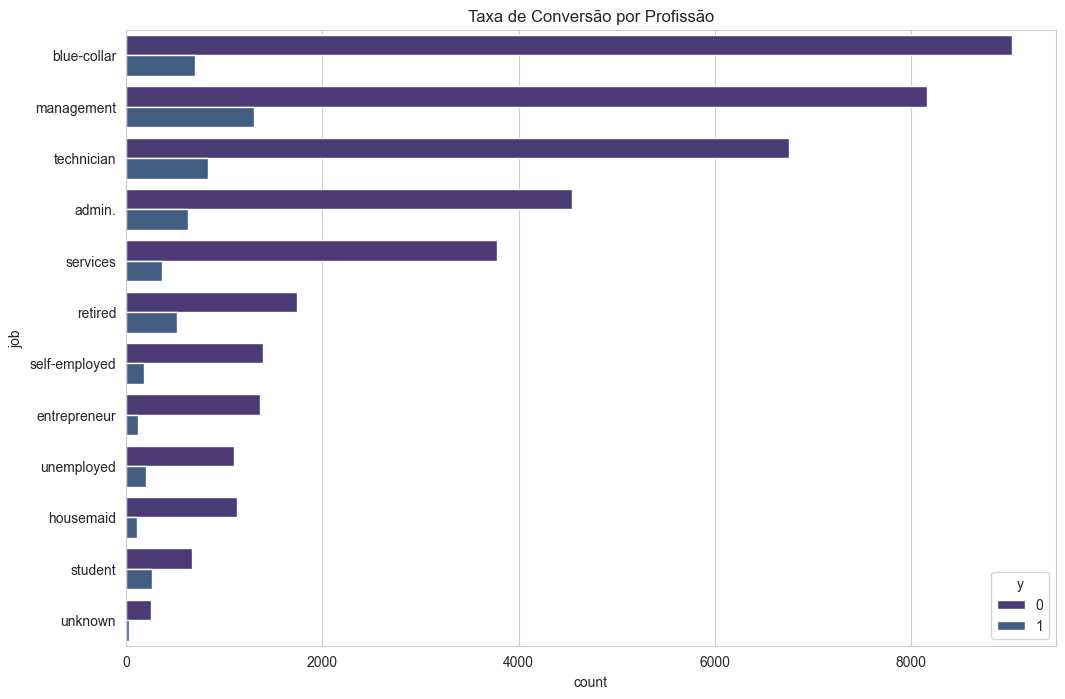

In [17]:
# Taxa de conversão por profissão
plt.figure(figsize=(12, 8))
sns.countplot(y="job", hue="y", data=df, order=df["job"].value_counts().index)
plt.title("Taxa de Conversão por Profissão")
plt.show()

In [18]:
"""
Comentario: Podemos observar que a taxa de conversão muda muito dependendo da profissão, sendo que os que trabalha como management tem a maior taxa de fazer isso e entrepreneur é a que tem menor taxa, junto de housemaid.
"""

'\nComentario: Podemos observar que a taxa de conversão muda muito dependendo da profissão, sendo que os que trabalha como management tem a maior taxa de fazer isso e entrepreneur é a que tem menor taxa, junto de housemaid.\n'

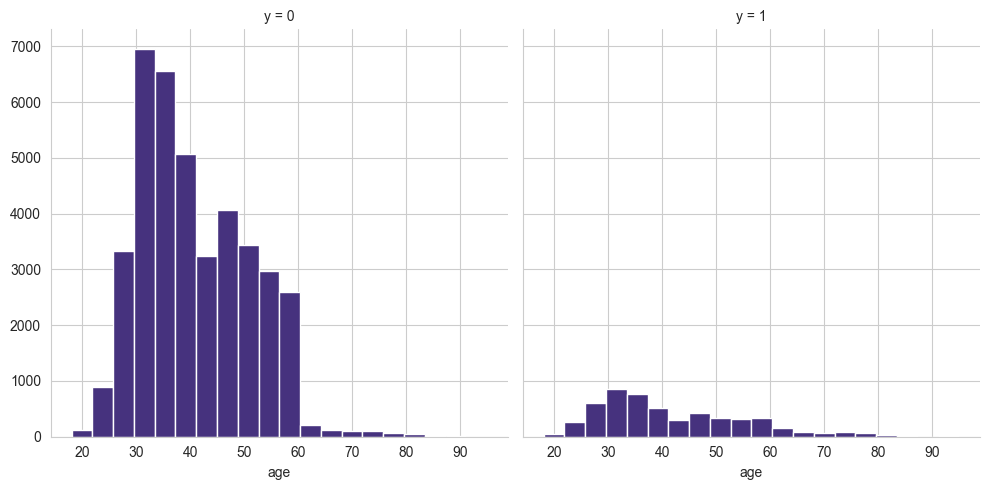

In [19]:
# Taxa de conversão por idade
g = sns.FacetGrid(df, col="y", height=5)
g.map(plt.hist, "age", bins=20)
plt.show()

In [20]:
"""
Comentario: Podemos observar que aqueles que tema  maior taxa de conversão estão na faixa de 25 a 40 anos.
"""

'\nComentario: Podemos observar que aqueles que tema  maior taxa de conversão estão na faixa de 25 a 40 anos.\n'

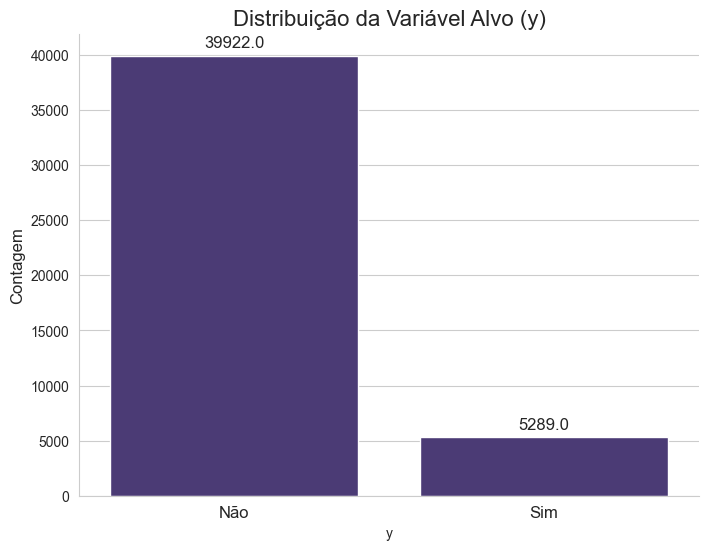

In [21]:
# Balanço das classes de saida.

# --- Geração do Gráfico ---
# Define a a paleta de cores
sns.set_palette("viridis")
# Cria a figura e os eixos para o gráfico
plt.figure(figsize=(8, 6))
# Cria o gráfico de contagem usando seaborn
# A ordem é definida para colocar o 'no' (maioria) primeiro
ax = sns.countplot(x="y", data=df, order=["0", "1"])
# Adiciona os rótulos de contagem em cima de cada barra
for p in ax.patches:
    ax.annotate(
        f"{p.get_height()}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
        fontsize=12,
    )
# Adiciona títulos e rótulos para melhor entendimento
plt.title("Distribuição da Variável Alvo (y)", fontsize=16)
plt.ylabel("Contagem", fontsize=12)
plt.xticks(
    ticks=[0, 1], labels=["Não", "Sim"], fontsize=12
)  # Renomeia os ticks do eixo x
# Remove a moldura superior e direita para um visual mais limpo
sns.despine()

In [22]:
"""
Comentario: Apenas 11,69% do total de clientes aceitou a proposta, o que a saida do nosso sistema altamente desbalanceado, isso vai ser um problema quando for fazer o uso de modelo de machine learning para classificação.
"""

'\nComentario: Apenas 11,69% do total de clientes aceitou a proposta, o que a saida do nosso sistema altamente desbalanceado, isso vai ser um problema quando for fazer o uso de modelo de machine learning para classificação.\n'

--- Taxa de Sucesso por Profissão ---
y                     0         1
job                              
student        0.713220  0.286780
retired        0.772085  0.227915
unemployed     0.844973  0.155027
management     0.862444  0.137556
admin.         0.877973  0.122027
self-employed  0.881571  0.118429
unknown        0.881944  0.118056
technician     0.889430  0.110570
services       0.911170  0.088830
housemaid      0.912097  0.087903
entrepreneur   0.917283  0.082717
blue-collar    0.927250  0.072750


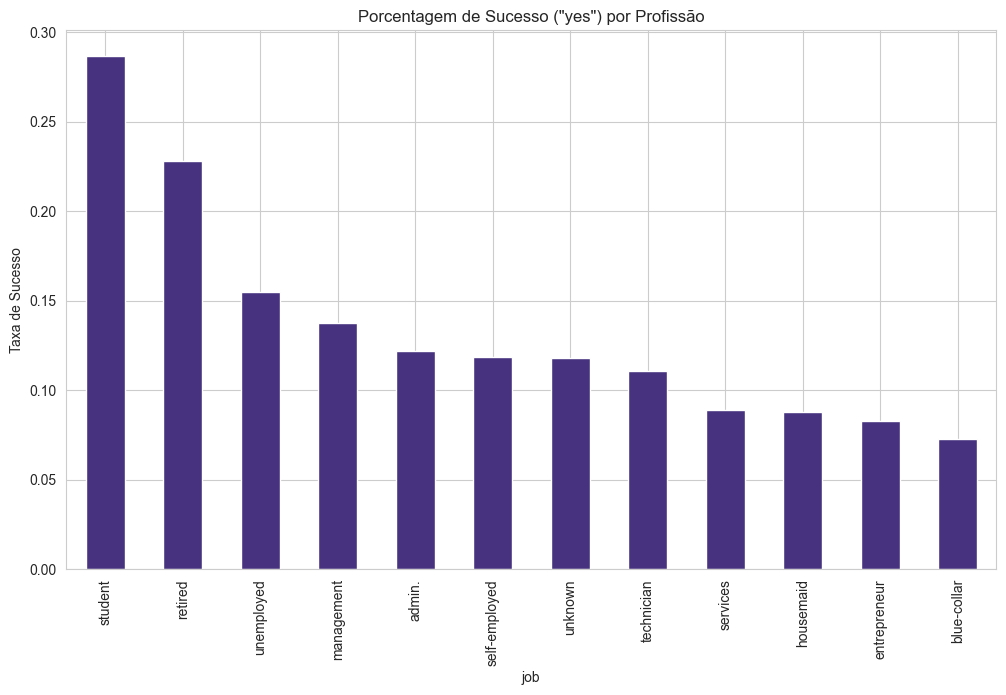

In [23]:
# Agrupa por 'job' e calcula a porcentagem de 'sim' e 'não' em cada grupo
taxa_sucesso_job = df.groupby("job")["y"].value_counts(normalize=True).unstack()
taxa_sucesso_job = taxa_sucesso_job.sort_values(by=1, ascending=False)

print("--- Taxa de Sucesso por Profissão ---")
print(taxa_sucesso_job)

# Plotar visualmente
taxa_sucesso_job[1].plot(
    kind="bar", figsize=(12, 7), title='Porcentagem de Sucesso ("yes") por Profissão'
)
plt.ylabel("Taxa de Sucesso")
plt.show()

In [24]:
"""
Comentario: Apesar de quantidade absoluta os que dizem mais sim ser Blue-collar e management, olhando para quantidade em % blue-collar é o menor, enquanto student geralmente são os que dizem mais sim, apesar que quando se olha em quantidade absoluta eles são os segundos menores.
"""

'\nComentario: Apesar de quantidade absoluta os que dizem mais sim ser Blue-collar e management, olhando para quantidade em % blue-collar é o menor, enquanto student geralmente são os que dizem mais sim, apesar que quando se olha em quantidade absoluta eles são os segundos menores.\n'

# Preparando os dados para analise.

In [25]:
colunas_numericas

['age', 'balance', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous']

In [26]:
"""
Comentario: Apenas a variavel day e month não tem um outliers, o que é totalmente esperado.
O atributo age possui 1,08% de outliers, um resultado ok.
O atributo balance possui 10,46% de outliers, um resultado muito grande.
O atributo duration possui 7,16% de outliers, um resultado muito grande.
O atributo camign possui 6,78% de outliers, um resultado muito grande.
o atributo pdays possui 18,26% de outliers, um resultado muito estranho, já que isso demostra que não é nenhum pouco equilibrado.
O atributo previous possui 18,26% de outliers, um resultado muito estranho, já que isso demostra que não é nenhum pouco equilibrado.
"""

'\nComentario: Apenas a variavel day e month não tem um outliers, o que é totalmente esperado.\nO atributo age possui 1,08% de outliers, um resultado ok.\nO atributo balance possui 10,46% de outliers, um resultado muito grande.\nO atributo duration possui 7,16% de outliers, um resultado muito grande.\nO atributo camign possui 6,78% de outliers, um resultado muito grande.\no atributo pdays possui 18,26% de outliers, um resultado muito estranho, já que isso demostra que não é nenhum pouco equilibrado.\nO atributo previous possui 18,26% de outliers, um resultado muito estranho, já que isso demostra que não é nenhum pouco equilibrado.\n'

In [27]:
# Aplicando MinMaxScaler de -1 até 1 para amenizar os outliers.
scaler = MinMaxScaler(feature_range=(0, 1))
df[colunas_numericas] = scaler.fit_transform(df[colunas_numericas])

In [28]:
# Aplicando One-Hot Encoding nas colunas textuais
df = pd.get_dummies(
    data=df,
    columns=colunas_textuais,
    drop_first=True,  # Boa prática para evitar multicolinearidade em modelos
)

# Analise das melhores features 

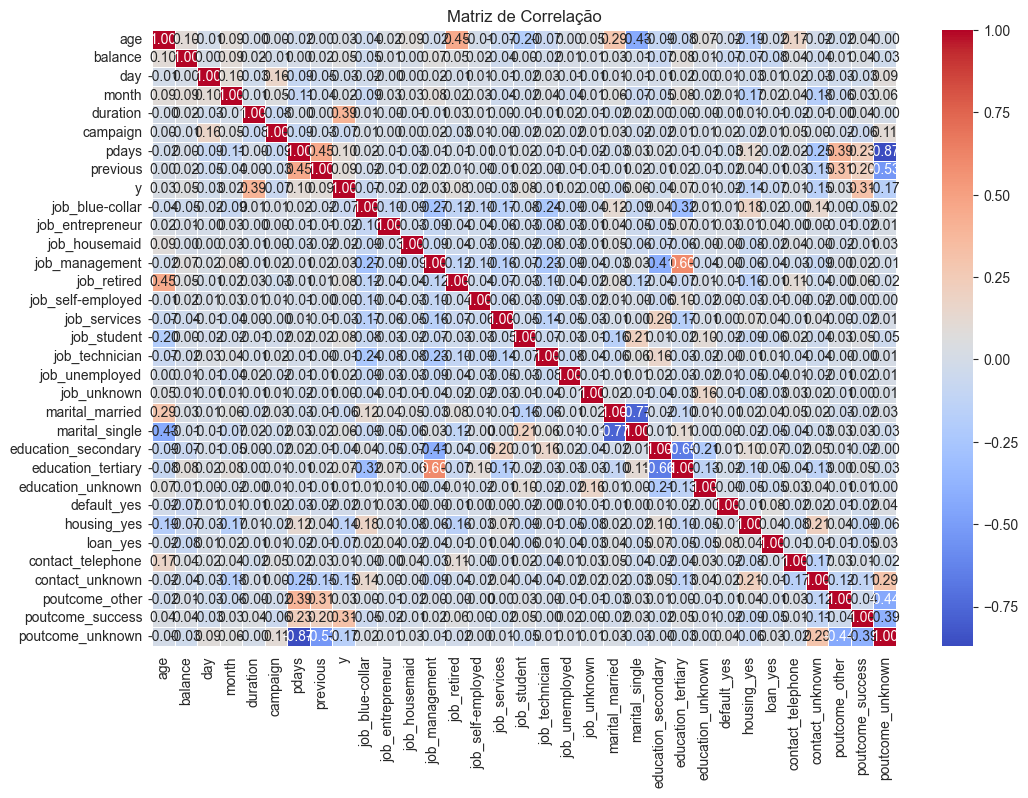

In [29]:
# Calculando a matriz de correlação
correlation_matrix = df.corr()

# Exibir a matriz de correlação com um heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlação")
plt.show()

In [30]:
"""
Comentario: Olhando a matrix posso ver de olhometro que o atributo mais importante para definir a saida 'y' é o atributo duration, já que tem o modulo do valor é o maior entre o resto. 
"""

"\nComentario: Olhando a matrix posso ver de olhometro que o atributo mais importante para definir a saida 'y' é o atributo duration, já que tem o modulo do valor é o maior entre o resto. \n"

,Feature,Importance
4,duration,0.120877
30,poutcome_success,0.079108
25,housing_yes,0.028599
28,contact_unknown,0.025288
31,poutcome_unknown,0.012103
15,job_student,0.011549
26,loan_yes,0.011499
22,education_tertiary,0.010799
8,job_blue-collar,0.009149
12,job_retired,0.008800


C:\Users\NVME\AppData\Local\Temp\ipykernel_10328\2017295556.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lasso_feature_importance["Feature"], y=lasso_feature_importance["Importance"], palette="magma")


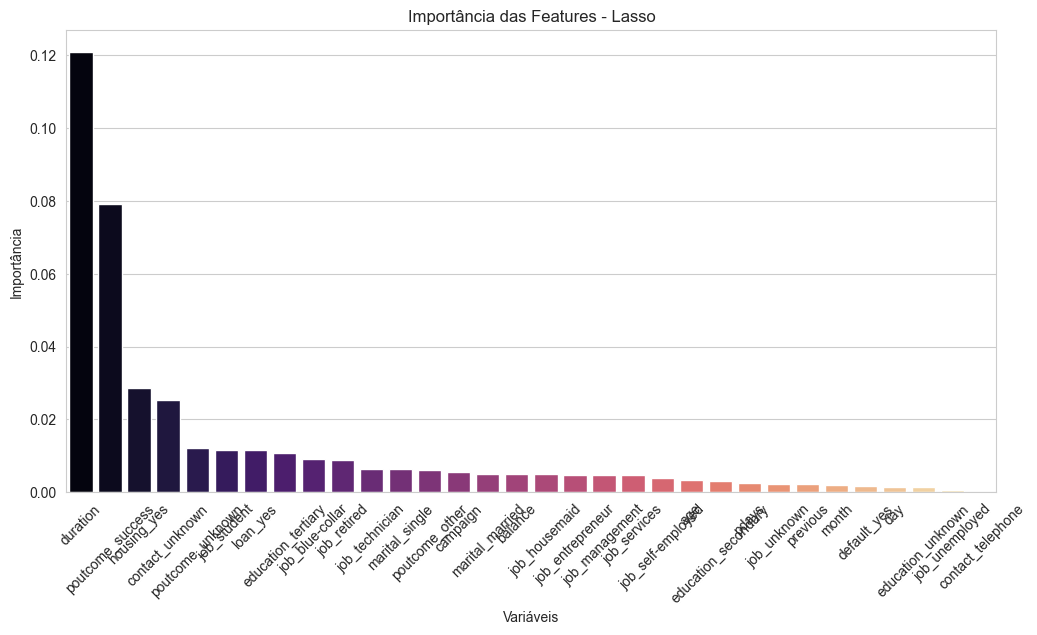

In [31]:
# --- Utilizando o coeficiente de Lasso. ---

# Separar variáveis independentes (X) e dependente (y)
X = df.drop(columns=["y"])  # MEDV é o preço da casa (target)
Y = df["y"]

# Dividir em treino e teste
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Normalizar os dados para o Lasso
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modelo Lasso com Cross-Validation
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, Y_train)

# Coeficientes do modelo Lasso
lasso_importance = np.abs(lasso.coef_)

# Criar DataFrame com os resultados
lasso_feature_importance = pd.DataFrame(
    {"Feature": X.columns, "Importance": lasso_importance}
).sort_values(by="Importance", ascending=False)

# Exibir a tabela
display(lasso_feature_importance)

# Plotar a importância das variáveis pelo Lasso
plt.figure(figsize=(12, 6))
sns.barplot(
    x=lasso_feature_importance["Feature"],
    y=lasso_feature_importance["Importance"],
    palette="magma",
)
plt.xticks(rotation=45)
plt.title("Importância das Features - Lasso")
plt.xlabel("Variáveis")
plt.ylabel("Importância")
plt.show()

In [32]:
"""
Comentario: Duration é o atributo mais importante de acordo com o coefieciente de lasso.
"""

'\nComentario: Duration é o atributo mais importante de acordo com o coefieciente de lasso.\n'

In [33]:
# --- Utilizando Random Forest para achar os melhores atributos. ----
# Modelo Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

# Importância das features no Random Forest
rf_importance = rf.feature_importances_

# Criar DataFrame com os resultados
rf_feature_importance = pd.DataFrame(
    {"Feature": X.columns, "Importance": rf_importance}
).sort_values(by="Importance", ascending=False)

# Exibir a tabela
display(rf_feature_importance)

# Plotar a importância das variáveis pelo Random Forest
plt.figure(figsize=(12, 6))
sns.barplot(
    x=rf_feature_importance["Feature"],
    y=rf_feature_importance["Importance"],
    palette="viridis",
)
plt.xticks(rotation=45)
plt.title("Importância das Features - Random Forest")
plt.xlabel("Variáveis")
plt.ylabel("Importância")
plt.show()

KeyboardInterrupt: 

In [ ]:
"""
Comentario: Duration é o atributo mais importante de acordo com o randomforest.
"""

'\nComentario: Duration é o atributo mais importante de acordo com o randomforest.\n'

In [ ]:
# Unir as duas tabelas em uma unica para selecionar as melhores pela média das duas.
# Unir (merge) os DataFrames usando o parâmetro 'suffixes'
merged_df = pd.merge(
    lasso_feature_importance,
    rf_feature_importance,
    on="Feature",
    suffixes=("_Lasso", "_RF"),
)

# Calcular a média e criar o novo DataFrame
merged_df["Average_Importance"] = (
    merged_df["Importance_Lasso"] + merged_df["Importance_RF"]
) / 2


# Criar o DataFrame final e ordenar
final_importance_df = merged_df[["Feature", "Average_Importance"]].sort_values(
    by="Average_Importance", ascending=False
)

print("--- DataFrame Final com a Média das Importâncias ---")
print(final_importance_df)

--- DataFrame Final com a Média das Importâncias ---
                Feature  Average_Importance
0              duration            0.199065
1      poutcome_success            0.066354
15              balance            0.054871
21                  age            0.051904
28                  day            0.047290
26                month            0.040495
2           housing_yes            0.026598
23                pdays            0.022882
13             campaign            0.022880
3       contact_unknown            0.020092
25             previous            0.012640
7    education_tertiary            0.011006
6              loan_yes            0.010848
4      poutcome_unknown            0.009072
8       job_blue-collar            0.009052
10       job_technician            0.008942
14      marital_married            0.008436
5           job_student            0.008014
11       marital_single            0.007932
22  education_secondary            0.007787
18       job_management

Total de features originais: 32
Features selecionadas pelo Lasso (importância > 0.01): 13

--- Tabela de Features Selecionadas ---


,Feature,Importance_Lasso,Importance_RF,Average_Importance
0,duration,0.120877,0.277254,0.199065
1,poutcome_success,0.079108,0.053599,0.066354
2,housing_yes,0.028599,0.024597,0.026598
3,contact_unknown,0.025288,0.014895,0.020092
6,loan_yes,0.011499,0.010197,0.010848
7,education_tertiary,0.010799,0.011214,0.011006
13,campaign,0.005454,0.040306,0.022880
15,balance,0.005024,0.104717,0.054871
21,age,0.003313,0.100495,0.051904
23,pdays,0.002474,0.043290,0.022882


C:\Users\NVME\AppData\Local\Temp\ipykernel_12248\3815269413.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Feature", y='Average_Importance', data=features_selecionadas_df, palette="magma")


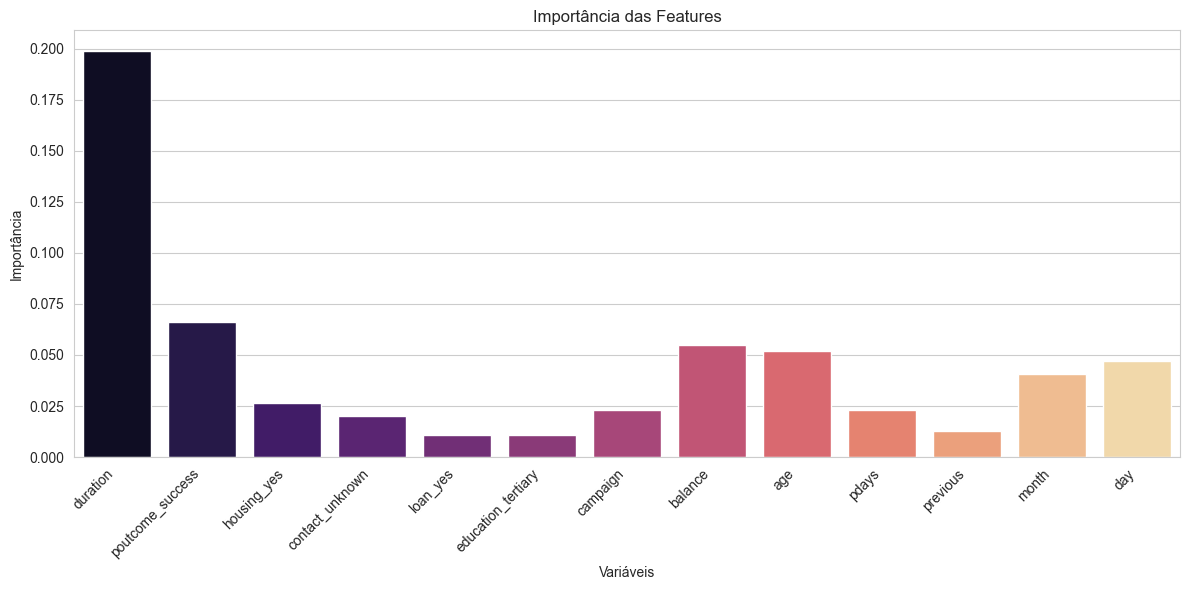

In [ ]:
# 1. Definir o limiar (threshold) de importância
limiar = 0.01

# 2. Filtrar o DataFrame para manter apenas as features acima do limiar
features_selecionadas_df = merged_df[merged_df["Average_Importance"] > limiar]

# 3. (Opcional, mas muito útil) Criar uma lista com os nomes das features selecionadas
lista_features_selecionadas = features_selecionadas_df["Feature"].tolist()

# Exibir a tabela APENAS com as features selecionadas
print(f"Total de features originais: {len(X.columns)}")
print(
    f"Features selecionadas pelo Lasso (importância > {limiar}): {len(lista_features_selecionadas)}"
)
print("\n--- Tabela de Features Selecionadas ---")
display(features_selecionadas_df)

# Plotar a importância APENAS das features selecionadas
plt.figure(figsize=(12, 6))
sns.barplot(
    x="Feature", y="Average_Importance", data=features_selecionadas_df, palette="magma"
)
plt.xticks(rotation=45, ha="right")  # ha='right' alinha melhor os rótulos
plt.title("Importância das Features")
plt.xlabel("Variáveis")
plt.ylabel("Importância")
plt.tight_layout()  # Ajusta o layout para não cortar os rótulos
plt.show()

In [ ]:
"""
Comentario: Um pequeno comentario sobre as features mais importantes:
Duration:  Se um cliente está engajado na conversa (resultando em uma chamada mais longa), a chance de sucesso é muito maior.
poutcome: Clientes que tiveram um resultado de "success" em campanhas anteriores têm uma probabilidade altíssima de aceitar a oferta novamente.
month: Ao analisar a taxa de sucesso por mês, você provavelmente verá que meses como Março, Setembro, Outubro e Dezembro têm uma taxa de sucesso muito maior, enquanto Maio (o mês com mais ligações) tem uma taxa baixa. 
housing:  Geralmente, a análise mostra que pessoas que NÃO têm um empréstimo imobiliário têm uma taxa de sucesso maior. Isso pode indicar que elas possuem maior liquidez financeira para investir.
Balance: A análise geralmente mostra que os clientes que dizem "sim" tendem a ter um saldo bancário ligeiramente maior. 
Age: A idade também pode mostrar padrões, como picos de sucesso em certas faixas etárias (ex: 30-40 anos e acima de 60).
"""

'\nComentario: Um pequeno comentario sobre as features mais importantes:\nDuration:  Se um cliente está engajado na conversa (resultando em uma chamada mais longa), a chance de sucesso é muito maior.\npoutcome: Clientes que tiveram um resultado de "success" em campanhas anteriores têm uma probabilidade altíssima de aceitar a oferta novamente.\nmonth: Ao analisar a taxa de sucesso por mês, você provavelmente verá que meses como Março, Setembro, Outubro e Dezembro têm uma taxa de sucesso muito maior, enquanto Maio (o mês com mais ligações) tem uma taxa baixa. \nhousing:  Geralmente, a análise mostra que pessoas que NÃO têm um empréstimo imobiliário têm uma taxa de sucesso maior. Isso pode indicar que elas possuem maior liquidez financeira para investir.\nBalance: A análise geralmente mostra que os clientes que dizem "sim" tendem a ter um saldo bancário ligeiramente maior. \nAge: A idade também pode mostrar padrões, como picos de sucesso em certas faixas etárias (ex: 30-40 anos e acima de

In [ ]:
# Reajustando X para ter só as variáveis escolhidas anteriormente.
X = X[lista_features_selecionadas]

# Dividir em treino e teste
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Normalizar os dados para o Lasso
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Machine Learning

## Machine Learning - Regressão Linear

### Machine Learning - Regressão Linear - Treinamento

In [ ]:
# Iniciar o modelo de regressão logística
modelo = LogisticRegression(
    random_state=42, solver="liblinear", max_iter=1000, class_weight="balanced"
)

# Treinar o modelo com os dados de treino
print("\nTreinando o modelo Regressao Logistica...")
modelo.fit(X_train, Y_train)
print("Modelo treinado com sucesso!")


Treinando o modelo Regressao Logistica...
Modelo treinado com sucesso!


In [ ]:
# Fazer previsões no conjunto de teste
Y_pred = modelo.predict(X_test)

# Avaliar o modelo
print("\n--- Avaliação do Modelo de Regressão Logística ---")

# Acurácia
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Acurácia: {accuracy:.4f}")

# Matriz de Confusão
print("\nMatriz de Confusão:")
print(confusion_matrix(Y_test, Y_pred))

# Relatório de Classificação
print("\nRelatório de Classificação:")
print(classification_report(Y_test, Y_pred))


--- Avaliação do Modelo de Regressão Logística ---
Acurácia: 0.8264

Matriz de Confusão:
[[6611 1341]
 [ 229  862]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.97      0.83      0.89      7952
           1       0.39      0.79      0.52      1091

    accuracy                           0.83      9043
   macro avg       0.68      0.81      0.71      9043
weighted avg       0.90      0.83      0.85      9043



### Machine Learning - Regressao Logistica - GrindSearchCV

In [ ]:
# Definir os parâmetros para o GridSearchCV para Regressão Logística
parametros = {
    "C": [1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],
}

# Melhores parametros encontrados
parametros = {"C": [1], "penalty": ["l1"], "solver": ["liblinear"]}
# {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}

In [ ]:
# Iniciar o modelo base
logreg = LogisticRegression(random_state=42)

In [ ]:
# Configurar o GridSearchCV
grid_search = GridSearchCV(
    logreg,
    param_grid=parametros,
    cv=5,  # cv=5 significa validação cruzada com 5 folds
    scoring="accuracy",  # scoring='accuracy' indica que queremos otimizar a acurácia
    n_jobs=-1,  # Usar todos os núcleos disponíveis
    verbose=1,  # Exibir progresso
)

In [ ]:
# Treinar o GrindSsearchCV nos dados de treino
print("\nIniciando o GridSearchCV...")
grid_search.fit(X_train, Y_train)
print("GridSearchCV concluído!")


Iniciando o GridSearchCV...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
GridSearchCV concluído!


In [ ]:
# Exibir os melhores hiperparâmetros e a melhor pontuação
print("\nMelhores hiperparâmetros encontrados:", grid_search.best_params_)
print(f"Melhor acurácia da validação cruzada:, {grid_search.best_score_:.4f}")

# Obter o melhor modelo treinado
best_model = grid_search.best_estimator_


Melhores hiperparâmetros encontrados: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Melhor acurácia da validação cruzada:, 0.9005


In [ ]:
# Avaliar o melhor modelo no conjunto de TESTE (o que realmente importa!)
y_pred_tuned = best_model.predict(X_test)

print("\n--- Avaliação do Melhor Modelo (Otimizado) no Conjunto de TESTE ---")
accuracy_tuned = accuracy_score(Y_test, y_pred_tuned)
print(f"Acurácia (otimizada): {accuracy_tuned:.4f}")
print("\nMatriz de Confusão (otimizada):")
print(confusion_matrix(Y_test, y_pred_tuned))
print("\nRelatório de Classificação (otimizado):")
print(classification_report(Y_test, y_pred_tuned))


--- Avaliação do Melhor Modelo (Otimizado) no Conjunto de TESTE ---
Acurácia (otimizada): 0.8973

Matriz de Confusão (otimizada):
[[7761  191]
 [ 738  353]]

Relatório de Classificação (otimizado):
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7952
           1       0.65      0.32      0.43      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043



## Machine Learning - Floresta Aleatoria (Random Forest)

### Machine Learning - Floresta Aleatoria (Random Forest) - Treinamento

In [ ]:
# Incializar o modelo Random Forest
modelo_rf = RandomForestClassifier(
    n_estimators=100,  # n_estimators: número de árvores na floresta (um bom ponto de partida é 100)
    class_weight="balanced",
    random_state=42,
)  # random_state: para reprodutibilidade

In [ ]:
# Treinar o modelo
print("\nTreinando o modelo Random Forest...")
modelo_rf.fit(X_train, Y_train)
print("Modelo Random Forest treinado com sucesso!")


Treinando o modelo Random Forest...
Modelo Random Forest treinado com sucesso!


In [ ]:
# Fazer previsões no conjunto de teste
Y_pred_rf = modelo_rf.predict(X_test)

In [ ]:
# Avaliar o modelo
print("\n--- Avaliação do Modelo Random Forest ---")

# Acurácia
accuracy_rf = accuracy_score(Y_test, Y_pred_rf)
print(f"Acurácia: {accuracy_rf:.4f}")

# Matriz de Confusão
print("\nMatriz de Confusão:")
print(confusion_matrix(Y_test, Y_pred_rf))

# Relatório de Classificação
print("\nRelatório de Classificação:")
print(classification_report(Y_test, Y_pred_rf))


--- Avaliação do Modelo Random Forest ---
Acurácia: 0.8995

Matriz de Confusão:
[[7734  218]
 [ 691  400]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.65      0.37      0.47      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.67      0.71      9043
weighted avg       0.89      0.90      0.89      9043



### Machine Learning - Floresta Aleatoria (Random Forest) - GridSearchCV

In [ ]:
# Definir os parâmetros para o GridSearchCV para Random Forest
# parametros_grid_rf = {
#    'n_estimators': [50, 100, 150, 200, 250],  # Número de árvores na floresta'
#    'criterion': ['gini', 'entropy', 'log_loss'],  # Critério de divisão
#    'max_depth': [None, 5, 10, 15, 20],  # Profundidade máxima das árvores
#    'min_samples_split': [2, 5, 10],  # Número mínimo de amostras necessárias para dividir um nó
#    'min_samples_leaf': [1, 2, 4],  # Número mínimo de amostras necessárias em um nó folha
#    'max_features': ['auto', 'sqrt', 'log2'],  # Número de recursos a serem considerados ao procurar a melhor divisão
#    'random_state': [42]  # Para reprodutibilidade
# }

# O melhor conjunto de parâmetros para o GridSearchCV para Random Forest
parametros_grid_rf = {
    "n_estimators": [200],  # Número de árvores na floresta'
    "criterion": ["gini"],  # Critério de divisão
    "max_depth": [20],  # Profundidade máxima das árvores
    "min_samples_split": [
        10
    ],  # Número mínimo de amostras necessárias para dividir um nó
    "min_samples_leaf": [1],  # Número mínimo de amostras necessárias em um nó folha
    "max_features": [
        "sqrt"
    ],  # Número de recursos a serem considerados ao procurar a melhor divisão
    "random_state": [42],  # Para reprodutibilidade
}

In [ ]:
# Inicializar o modelo base Random Forest
rf_base = RandomForestClassifier()

In [ ]:
# Configurar o GridSearchCV para Random Forest
grid_search_rf = GridSearchCV(
    rf_base,
    param_grid=parametros_grid_rf,
    cv=5,  # Validação cruzada com 5 folds
    scoring="accuracy",  # Otimizar a acurácia
    n_jobs=-1,  # Usar todos os núcleos disponíveis
    verbose=1,  # Exibir progresso
)

In [ ]:
# Treinar o GridSearchCV nos dados de treino
print("\nIniciando o GridSearchCV para Random Forest...")
grid_search_rf.fit(X_train, Y_train)
print("GridSearchCV para Random Forest concluído!")


Iniciando o GridSearchCV para Random Forest...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
GridSearchCV para Random Forest concluído!


In [ ]:
# Exibir os melhores hiperparâmetros e a melhor pontuação de validação cruzada
print(
    "\nMelhores hiperparâmetros encontrados para Random Forest:",
    grid_search_rf.best_params_,
)
print(
    f"Melhor acurácia da validação cruzada para Random Forest: {grid_search_rf.best_score_:.4f}"
)


Melhores hiperparâmetros encontrados para Random Forest: {'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200, 'random_state': 42}
Melhor acurácia da validação cruzada para Random Forest: 0.9070


In [ ]:
# Obter o melhor modelo treinado
best_rf_model = grid_search_rf.best_estimator_

In [ ]:
# Avaliar o melhor modelo Random Forest no conjunto de TESTE
y_pred_rf_tuned = best_rf_model.predict(X_test)

print(
    "\n--- Avaliação do Melhor Modelo Random Forest (Otimizado) no Conjunto de TESTE ---"
)
accuracy_rf_tuned = accuracy_score(Y_test, y_pred_rf_tuned)
print(f"Acurácia (Random Forest otimizado): {accuracy_rf_tuned:.4f}")
print("\nMatriz de Confusão (Random Forest otimizado):")
print(confusion_matrix(Y_test, y_pred_rf_tuned))
print("\nRelatório de Classificação (Random Forest otimizado):")
print(classification_report(Y_test, y_pred_rf_tuned))


--- Avaliação do Melhor Modelo Random Forest (Otimizado) no Conjunto de TESTE ---
Acurácia (Random Forest otimizado): 0.9007

Matriz de Confusão (Random Forest otimizado):
[[7694  258]
 [ 640  451]]

Relatório de Classificação (Random Forest otimizado):
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.64      0.41      0.50      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043



In [ ]:
# # Plotar uma Árvore de Decisão do Random Forest
# feature_names = X.columns.tolist()

# plt.figure(figsize=(25, 15)) # Ajuste o tamanho para melhor visualização
# plot_tree(modelo_rf.estimators_[0], # Seleciona a primeira árvore da floresta (índice 0)
#           feature_names=feature_names, # Nome das features
#           class_names=['0', '1'], # Nomes das classes
#           filled=True, # Preencher os nós com cores
#           rounded=True, # Cantos arredondados
#           fontsize=10) # Tamanho da fonte
# plt.title("Visualização de Uma Árvore de Decisão do Random Forest Otimizado", fontsize=18)
# plt.show()

# print("\nPrimeiras 5 linhas de X_train (para referência das colunas):")
# print(X_train.head())

## Machine Learning - XGBoost

### Machine Learning - XGBoost - Treinando

In [ ]:
# Inicializar o modelo XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,  # Número de árvores
    learning_rate=0.1,  # Taxa de aprendizado
    random_state=42,  # Para reprodutibilidade
    use_label_encoder=False,  # Para evitar warnings recentes do XGBoost
    eval_metric="logloss",
)  # Métrica de avaliação

In [ ]:
# Treinar o modelo
print("\nTreinando o modelo XGBoost...")
xgb_model.fit(X_train, Y_train)
print("Modelo XGBoost treinado com sucesso!")


Treinando o modelo XGBoost...


C:\Users\NVME\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [09:42:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Modelo XGBoost treinado com sucesso!


In [ ]:
# Fazer previsões no conjunto de teste
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
# Avaliar o modelo
print("\nAvaliação do Modelo XGBoost")

# Acurácia
accuracy_xgb = accuracy_score(Y_test, y_pred_xgb)
print(f"Acurácia: {accuracy_xgb:.4f}")

# Matriz de Confusão
print("\nMatriz de Confusão:")
print(confusion_matrix(Y_test, y_pred_xgb))

# Relatório de Classificação
print("\nRelatório de Classificação:")
print(classification_report(Y_test, y_pred_xgb))


Avaliação do Modelo XGBoost
Acurácia: 0.9077

Matriz de Confusão:
[[7687  265]
 [ 570  521]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7952
           1       0.66      0.48      0.56      1091

    accuracy                           0.91      9043
   macro avg       0.80      0.72      0.75      9043
weighted avg       0.90      0.91      0.90      9043



### Machine Learning - XGBoost - GridSearchCV

In [ ]:
# Definir a grade de hiperparâmetros para XGBoost
param_grid_xgb = {
    "n_estimators": [100, 200, 300],  # Número de árvores
    "learning_rate": [0.01, 0.05, 0.1],  # Taxa de aprendizado
    "max_depth": [3, 5, 7],  # Profundidade máxima de cada árvore
    "subsample": [0.7, 0.9],  # Pode adicionar mais aqui se quiser explorar
    "colsample_bytree": [0.7, 0.9],  # Pode adicionar mais aqui
    "gamma": [0, 0.1, 0.2],  # Regularização
    "random_state": [42],  # Para reprodutibilidade
}

# Melhores parametros achado
param_grid_xgb = {
    "n_estimators": [200],  # Número de árvores
    "learning_rate": [0.1],  # Taxa de aprendizado
    "max_depth": [5],  # Profundidade máxima de cada árvore
    "subsample": [0.7],  # Pode adicionar mais aqui se quiser explorar
    "colsample_bytree": [0.9],  # Pode adicionar mais aqui
    "gamma": [0.2],  # Regularização
    "random_state": [42],  # Para reprodutibilidade
}
# {'colsample_bytree': 0.9, 'gamma': 0.2, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'random_state': 42, 'subsample': 0.7}

In [ ]:
# Inicializar o modelo base XGBoost
xgb_base = xgb.XGBClassifier(
    use_label_encoder=False,  # Para evitar warnings recentes do XGBoost,
    eval_metric="logloss",  # Definindo a métrica de avaliação
)

In [ ]:
# Configurar o GridSearchCV para XGBoost
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=5,  # Validação cruzada com 5 folds
    scoring="accuracy",  # Métrica de avaliação
    n_jobs=-1,  # Usar todos os núcleos disponíveis
    verbose=1,  # Exibir progresso
)

In [ ]:
# Treinar o GridSearchCV nos dados de TREINO
print("\nIniciando a busca em grade para otimização de hiperparâmetros do XGBoost...")
grid_search_xgb.fit(X_train, Y_train)
print("Busca em grade concluída!")


Iniciando a busca em grade para otimização de hiperparâmetros do XGBoost...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\NVME\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [09:42:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Busca em grade concluída!


In [ ]:
# Exibir os melhores hiperparâmetros e a melhor pontuação de validação cruzada
print(
    "\nMelhores hiperparâmetros encontrados para XGBoost:", grid_search_xgb.best_params_
)
print(
    f"Melhor acurácia da validação cruzada para XGBoost: {grid_search_xgb.best_score_:.4f}"
)


Melhores hiperparâmetros encontrados para XGBoost: {'colsample_bytree': 0.9, 'gamma': 0.2, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'random_state': 42, 'subsample': 0.7}
Melhor acurácia da validação cruzada para XGBoost: 0.9096


In [ ]:
# Obter o melhor modelo treinado
best_xgb_model = grid_search_xgb.best_estimator_

In [ ]:
# Avaliar o melhor modelo XGBoost no conjunto de TESTE
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

print("\n--- Avaliação do Melhor Modelo XGBoost (Otimizado) no Conjunto de TESTE ---")
accuracy_xgb_tuned = accuracy_score(Y_test, y_pred_xgb_tuned)
print(f"Acurácia (XGBoost otimizado): {accuracy_xgb_tuned:.4f}")
print("\nMatriz de Confusão (XGBoost otimizado):")
print(confusion_matrix(Y_test, y_pred_xgb_tuned))
print("\nRelatório de Classificação (XGBoost otimizado):")
print(classification_report(Y_test, y_pred_xgb_tuned))


--- Avaliação do Melhor Modelo XGBoost (Otimizado) no Conjunto de TESTE ---
Acurácia (XGBoost otimizado): 0.9094

Matriz de Confusão (XGBoost otimizado):
[[7690  262]
 [ 557  534]]

Relatório de Classificação (XGBoost otimizado):
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7952
           1       0.67      0.49      0.57      1091

    accuracy                           0.91      9043
   macro avg       0.80      0.73      0.76      9043
weighted avg       0.90      0.91      0.90      9043



Plotando a Matriz de Confusão para o modelo XGBoost...


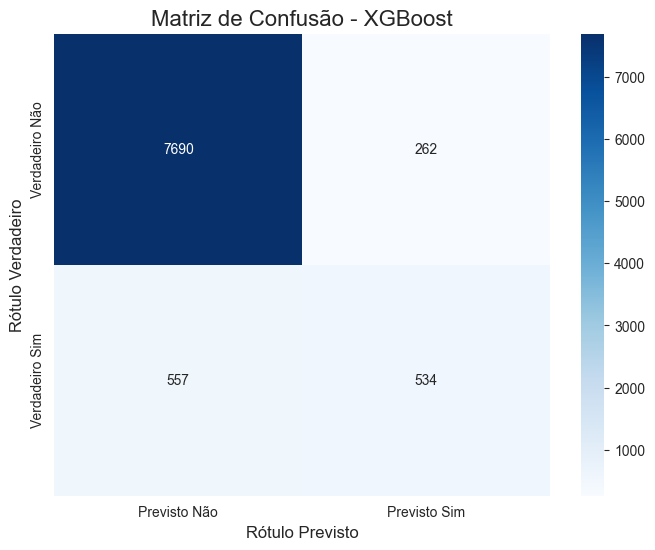

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# --- Função para Plotar a Matriz de Confusão ---
def plotar_matriz_confusao(y_verdadeiro, y_previsao, nome_modelo):
    """
    Plota uma Matriz de Confusão customizada e visualmente agradável.

    Argumentos:
    y_verdadeiro -- Rótulos verdadeiros (Y_test).
    y_previsao -- Rótulos previstos pelo modelo (y_pred).
    nome_modelo -- Uma string com o nome do modelo para o título do gráfico.
    """
    # Calcula a matriz de confusão
    cm = confusion_matrix(y_verdadeiro, y_previsao)

    # Cria a figura
    plt.figure(figsize=(8, 6))

    # Plota o heatmap do Seaborn
    sns.heatmap(
        cm,
        annot=True,  # anota os valores em cada célula
        fmt="d",  # formata os valores como inteiros
        cmap="Blues",  # define o mapa de cores
        xticklabels=["Previsto Não", "Previsto Sim"],
        yticklabels=["Verdadeiro Não", "Verdadeiro Sim"],
    )

    # Adiciona títulos e rótulos
    plt.title(f"Matriz de Confusão - {nome_modelo}", fontsize=16)
    plt.ylabel("Rótulo Verdadeiro", fontsize=12)
    plt.xlabel("Rótulo Previsto", fontsize=12)

    # Mostra o gráfico
    plt.show()


# --- Exemplo de como usar a função com seu modelo XGBoost ---
# (Assumindo que você já tenha 'Y_test' e 'y_pred_xgb_tuned' do seu código)

print("Plotando a Matriz de Confusão para o modelo XGBoost...")
plotar_matriz_confusao(Y_test, y_pred_xgb_tuned, "XGBoost")

# --- Você pode chamar a função para outros modelos também ---

# print("\nPlotando a Matriz de Confusão para o modelo Random Forest...")
# plotar_matriz_confusao(Y_test, y_pred_rf_tuned, "Random Forest Otimizado")

## Machine Learning - K-nn

### Machine Learning - K-nn - Treinamento

In [ ]:
# Inicializar o modelo KNN
knn_model = KNeighborsClassifier(
    n_neighbors=213  # Número de vizinhos a serem considerados
)

In [ ]:
# Treinar o modelo
print("\nTreinando o modelo KNN...")
knn_model.fit(X_train, Y_train)
print("Modelo KNN treinado com sucesso!")


Treinando o modelo KNN...
Modelo KNN treinado com sucesso!


In [ ]:
# Fazer previsões no conjunto de teste
Y_pred_knn = knn_model.predict(X_test)

In [ ]:
# Avaliar o modelo
print("\nAvaliação do Modelo KNN ")

# Acurácia
accuracy_knn = accuracy_score(Y_test, Y_pred_knn)
print(f"Acurácia: {accuracy_knn:.4f}")

# Matriz de Confusão
print("\nMatriz de Confusão:")
print(confusion_matrix(Y_test, Y_pred_knn))

# Relatório de Classificação
print("\nRelatório de Classificação:")
print(classification_report(Y_test, Y_pred_knn))


Avaliação do Modelo KNN 
Acurácia: 0.8945

Matriz de Confusão:
[[7801  151]
 [ 803  288]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7952
           1       0.66      0.26      0.38      1091

    accuracy                           0.89      9043
   macro avg       0.78      0.62      0.66      9043
weighted avg       0.88      0.89      0.87      9043



### Machine Learning - K-nn - GridSearchCV

In [ ]:
# Definir a grade de hiperparâmetros para K-nn
param_grid_knn = {
    "n_neighbors": [
        203,
        205,
        207,
        209,
        211,
        213,
        215,
        217,
        219,
        221,
        223,
    ],  # Valores comuns para K
    "weights": [
        "uniform",
        "distance",
    ],  # Uniform: todos vizinhos contam igual; Distance: vizinhos mais próximos contam mais
    "metric": ["euclidean", "manhattan"],  # Funções de distância
}

# Melhor conjunto de parâmetros para o GridSearchCV para K-nn
param_grid_knn = {
    "n_neighbors": [213],  # Valores comuns para K
    "weights": [
        "distance"
    ],  # Uniform: todos vizinhos contam igual; Distance: vizinhos mais próximos contam mais
    "metric": ["euclidean"],  # Funções de distância
}
# {'metric': 'euclidean', 'n_neighbors': 213, 'weights': 'distance'}

In [ ]:
# Inicializar o modelo base KNN
knn_base = KNeighborsClassifier()

In [ ]:
# Configurar o GridSearchCV para KNN
grid_search_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid_knn,
    cv=5,  # Validação cruzada com 5 folds
    scoring="accuracy",  # Métrica de avaliação
    n_jobs=-1,  # Usar todos os núcleos disponíveis
    verbose=1,  # Exibir progresso
)

In [ ]:
# Treinar o GridSearchCV nos dados de TREINO
print("\nIniciando a busca em grade para otimização de hiperparâmetros do KNN...")
grid_search_knn.fit(X_train, Y_train)
print("Busca em grade concluída!")


Iniciando a busca em grade para otimização de hiperparâmetros do KNN...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Busca em grade concluída!


In [ ]:
# Exibir os melhores hiperparâmetros e a melhor pontuação de validação cruzada
print("\nMelhores hiperparâmetros encontrados para KNN:", grid_search_knn.best_params_)
print(
    f"Melhor acurácia da validação cruzada para KNN: {grid_search_knn.best_score_:.4f}"
)


Melhores hiperparâmetros encontrados para KNN: {'metric': 'euclidean', 'n_neighbors': 213, 'weights': 'distance'}
Melhor acurácia da validação cruzada para KNN: 0.8966


In [ ]:
# Obter o melhor modelo treinado
best_knn_model = grid_search_knn.best_estimator_

In [ ]:
# Avaliar o melhor modelo KNN no conjunto de TESTE
y_pred_knn_tuned = best_knn_model.predict(X_test)

print("\n--- Avaliação do Melhor Modelo KNN (Otimizado) no Conjunto de TESTE ---")
accuracy_knn_tuned = accuracy_score(Y_test, y_pred_knn_tuned)
print(f"Acurácia (KNN otimizado): {accuracy_knn_tuned:.4f}")
print("\nMatriz de Confusão (KNN otimizado):")
print(confusion_matrix(Y_test, y_pred_knn_tuned))
print("\nRelatório de Classificação (KNN otimizado):")
print(classification_report(Y_test, y_pred_knn_tuned))


--- Avaliação do Melhor Modelo KNN (Otimizado) no Conjunto de TESTE ---
Acurácia (KNN otimizado): 0.8952

Matriz de Confusão (KNN otimizado):
[[7800  152]
 [ 796  295]]

Relatório de Classificação (KNN otimizado):
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7952
           1       0.66      0.27      0.38      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.63      0.66      9043
weighted avg       0.88      0.90      0.88      9043



## Machine Learning - SVM 

### Machine Learning - SVM - Treinamento

In [ ]:
# Inicializar o modelo SVM
svm_model = SVC(
    kernel="rbf",  # Kernel radial basis function (RBF)
    C=1.0,  # Parâmetro de regularização
    gamma="scale",  # Parâmetro de escala para o kernel RBF
    random_state=42,  # Para reprodutibilidade
    probability=True,  # Habilitar a previsão de probabilidades
)

In [ ]:
# Treinar o modelo
print("\nTreinando o modelo SVM...")
svm_model.fit(X_train, Y_train)
print("Modelo SVM treinado com sucesso!")


Treinando o modelo SVM...
Modelo SVM treinado com sucesso!


In [ ]:
# Fazer previsões no conjunto de teste
y_pred_svm = svm_model.predict(X_test)

In [ ]:
# Avaliar o modelo
print("\n--- Avaliação do Modelo SVM ---")

# Acurácia
accuracy_svm = accuracy_score(Y_test, y_pred_svm)
print(f"Acurácia: {accuracy_svm:.4f}")

# Matriz de Confusão
print("\nMatriz de Confusão:")
print(confusion_matrix(Y_test, y_pred_svm))

# Relatório de Classificação
print("\nRelatório de Classificação:")
print(classification_report(Y_test, y_pred_svm))


--- Avaliação do Modelo SVM ---
Acurácia: 0.8974

Matriz de Confusão:
[[7786  166]
 [ 762  329]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7952
           1       0.66      0.30      0.41      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.64      0.68      9043
weighted avg       0.88      0.90      0.88      9043



### Machine Learning - SVM - GridSearchCV

In [ ]:
# Definir a grade de hiperparâmetros para SVM
param_grid_svm = {
    "C": [0.1, 1, 10, 100],  # Parâmetro de regularização (menor C = mais regularização)
    "gamma": [
        0.001,
        0.01,
        0.1,
        1,
    ],  # Parâmetro do kernel (impacta a forma da fronteira de decisão)
    "kernel": [
        "rbf"
    ],  # O kernel RBF é um bom ponto de partida, mas você pode testar outros como 'linear', 'poly'
}

# Melhores parametros
param_grid_svm = {
    "C": [10],  # Parâmetro de regularização (menor C = mais regularização)
    "gamma": [0.1],  # Parâmetro do kernel (impacta a forma da fronteira de decisão)
    "kernel": [
        "rbf"
    ],  # O kernel RBF é um bom ponto de partida, mas você pode testar outros como 'linear', 'poly'
}
# {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

In [ ]:
# Inicializar o modelo base SVM
svm_base = SVC(
    random_state=42,
    probability=True,  # Habilitar a previsão de probabilidades
)

In [ ]:
# Configurar o GridSearchCV para SVM
grid_search_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid_svm,
    cv=5,  # Validação cruzada com 5 folds
    scoring="accuracy",  # Otimizar pela acurácia
    n_jobs=-1,  # Usar todos os núcleos disponíveis
    verbose=1,
)  # verbose=1 para ver o progresso

In [ ]:
# 5. Treinar o GridSearchCV nos dados de TREINO
print("\nIniciando a busca em grade para otimização de hiperparâmetros do SVM...")
grid_search_svm.fit(X_train, Y_train)
print("Busca em grade concluída!")


Iniciando a busca em grade para otimização de hiperparâmetros do SVM...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Busca em grade concluída!


In [ ]:
# Exibir os melhores hiperparâmetros e a melhor pontuação de validação cruzada
print("\nMelhores hiperparâmetros encontrados para SVM:", grid_search_svm.best_params_)
print(
    f"Melhor acurácia da validação cruzada para SVM: {grid_search_svm.best_score_:.4f}"
)


Melhores hiperparâmetros encontrados para SVM: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Melhor acurácia da validação cruzada para SVM: 0.9016


In [ ]:
# Obter o melhor modelo treinado
best_svm_model = grid_search_svm.best_estimator_

In [ ]:
# Avaliar o melhor modelo SVM no conjunto de TESTE
y_pred_svm_tuned = best_svm_model.predict(X_test)

print("\n--- Avaliação do Melhor Modelo SVM (Otimizado) no Conjunto de TESTE ---")
accuracy_svm_tuned = accuracy_score(Y_test, y_pred_svm_tuned)
print(f"Acurácia (SVM otimizado): {accuracy_svm_tuned:.4f}")
print("\nMatriz de Confusão (SVM otimizado):")
print(confusion_matrix(Y_test, y_pred_svm_tuned))
print("\nRelatório de Classificação (SVM otimizado):")
print(classification_report(Y_test, y_pred_svm_tuned))


--- Avaliação do Melhor Modelo SVM (Otimizado) no Conjunto de TESTE ---
Acurácia (SVM otimizado): 0.8969

Matriz de Confusão (SVM otimizado):
[[7750  202]
 [ 730  361]]

Relatório de Classificação (SVM otimizado):
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7952
           1       0.64      0.33      0.44      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043

